In [1]:
import numpy as np
import swarmData as swarm
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

In [2]:
refs = ['AlAminLucas1987','GoldenFisher1961','Kruithof1940','KucukarpaciLucas1981','MilloyCrompton1977','NakamuraKurachi1988','PackPhelps1961','Robertson1977','RobertsonRee1972','Specht1980','Tachibana1986']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
    filename = '../swarm/%s.txt' % ref
    swarms.append( swarm.swarmData(filename) )
    print(swarms[idx].ref)
    for dataset in swarms[idx].datasets:
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Al-Amin, S. A. J., & Lucas, J. (1987). Time of flight measurements of the ratio of radial diffusion coefficient and mobility for electron swarms in helium, argon, neon and krypton at high E/N. Journal of Physics D: Applied Physics, 20(12), 1590–1595. https://doi.org/10.1088/0022-3727/20/12/007
['E/N', 'DT/mu']
[[  56.5     6.4 ]
 [  84.8     7.66]
 [ 113.      7.35]
 [ 141.      7.79]
 [ 198.      7.11]
 [ 254.      7.38]
 [ 424.      7.45]
 [ 565.      8.05]
 [ 678.      8.55]
 [ 848.      8.86]
 [1130.     11.2 ]
 [1413.     11.8 ]
 [1695.     13.  ]
 [1978.     14.6 ]
 [2260.     15.1 ]
 [2825.     16.4 ]
 [3390.     15.2 ]
 [4238.     14.  ]
 [5650.     12.8 ]]
Golden, D. E., & Fisher, L. H. (1961). Anomalies in ionization coefficients and in uniform field breakdown in argon for low values of Ep. Physical Review, 123(4), 1079–1086. https://doi.org/10.1103/PhysRev.123.1079
['E/p', 'a/p']
[[5.00000e+00 1.52402e-05]
 [5.00000e+00 3.54028e-05]
 [6.00000e+00 2.01797e-04]
 [6.00000e+00 3

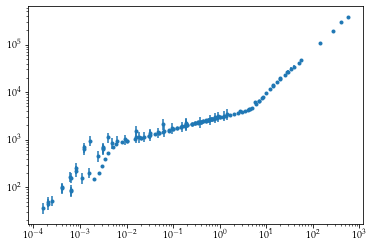

In [8]:
temp = np.copy(swarms[3].datasets[1].data)
temp[:,1] *= 1e4
error = temp[:,1][...,None] * 0.05
W = np.append( temp, error, axis=1 )

filename = '../swarm/W.%s.txt' % refs[3]
np.savetxt(filename,W,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[5].datasets[0].data)
temp[:,1] *= 1e3
temp[:,2] *= 0.02*temp[:,1]
W = np.append( W, temp, axis=0)

filename = '../swarm/W.%s.txt' % refs[5]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

kB, Td = 1.38064852e-23, 1.0e21
T = 77
temp = np.copy(swarms[6].datasets[0].data)
temp[:,0] *= 100. / 133.322 * kB * T * Td
temp[:,1] *= 1e-2
error = temp[:,1][...,None] * 0.25
temp = np.append( temp, error, axis=1 )
W = np.append( W, temp, axis=0)

filename = '../swarm/W.%s.77.txt' % refs[6]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

T = 300
temp = np.copy(swarms[6].datasets[1].data)
temp[:,0] *= 100. / 133.322 * kB * T * Td
temp[:,1] *= 1e-2
error = temp[:,1][...,None] * 0.25
temp = np.append( temp, error, axis=1 )
W = np.append( W, temp, axis=0)

filename = '../swarm/W.%s.300.txt' % refs[6]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

T = 293.
temp = np.copy(swarms[7].datasets[0].data)
temp[:,1] *= 1e3
temp[:,2] *= temp[:,1] * 0.01
W = np.append( W, temp, axis=0)

filename = '../swarm/W.%s.293.txt' % refs[7]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

T = 89.6
temp = np.copy(swarms[7].datasets[1].data)
temp[:,1] *= 1e3
temp[:,2] *= temp[:,1] * 0.01
W = np.append( W, temp, axis=0)

filename = '../swarm/W.%s.90.txt' % refs[7]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

plt.figure(1)
plt.errorbar(W[:,0],W[:,1],yerr=W[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

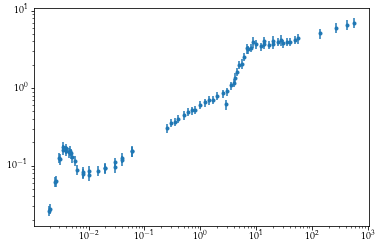

In [9]:
temp = np.copy(swarms[3].datasets[0].data)
error = temp[:,1][...,None] * 0.15
DLmu = np.append( temp, error, axis=1 )

filename = '../swarm/DLmu.%s.txt' % refs[3]
np.savetxt(filename,DLmu,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[5].datasets[0].data)
temp[:,1] = temp[:,2]/(temp[:,1]/temp[:,0]) * 1e24 / 1e3 * 1e-21
temp[:,2] = temp[:,1] * 0.12
DLmu = np.append( DLmu, temp, axis=0)

filename = '../swarm/DLmu.%s.txt' % refs[5]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[8].datasets[0].data)
error = temp[:,1][...,None] * 0.05 * 3
temp = np.append( temp, error, axis=1 )
DLmu = np.append( DLmu, temp, axis=0)

filename = '../swarm/DLmu.%s.700.txt' % refs[8]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[8].datasets[1].data)
error = temp[:,1][...,None] * 0.05 * 3
temp = np.append( temp, error, axis=1 )
DLmu = np.append( DLmu, temp, axis=0)

filename = '../swarm/DLmu.%s.800.txt' % refs[8]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

plt.figure(1)
plt.errorbar(DLmu[:,0],DLmu[:,1],yerr=DLmu[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

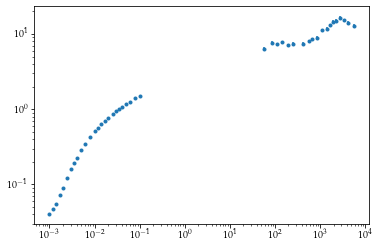

In [10]:
error = swarms[0].datasets[0].data[:,1][...,None]
DTmu = np.append( swarms[0].datasets[0].data, error*0.05, axis=1 )

filename = '../swarm/DTmu.%s.txt' % refs[0]
np.savetxt(filename,DTmu,fmt='%.15E',delimiter=' ')

temp = swarms[4].datasets[0].data
temp[:,2] *= 0.01*temp[:,1]

filename = '../swarm/DTmu.%s.txt' % refs[4]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

DTmu = np.append( DTmu, temp, axis=0)

plt.figure(1)
plt.errorbar(DTmu[:,0],DTmu[:,1],yerr=DTmu[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

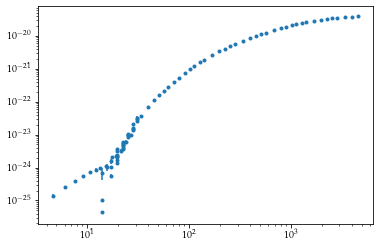

In [11]:
T = 273.15
temp = np.copy(swarms[1].datasets[0].data)
temp[:,0] *= 100. / 133.322 * kB * T * Td
temp[:,1] *= 100. / 133.322 * kB * T
error = temp[:,1][...,None] * 0.10
ion = np.append( temp, error, axis=1 )

filename = '../swarm/aion.%s.txt' % refs[1]
np.savetxt(filename,ion,fmt='%.15E',delimiter=' ')

T = 273.15
temp = np.copy(swarms[2].datasets[0].data)
temp[:,0] *= 100. / 133.322 * kB * T
temp[:,1] *= temp[:,0] 
temp[:,2] *= temp[:,0]
temp[:,0] *= Td
# ion = temp
ion = np.append( ion, temp, axis=0)

filename = '../swarm/aion.%s.txt' % refs[2]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[-2].datasets[0].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4 
temp[:,2] *= 1e-4
# ion = temp
ion = np.append( ion, temp, axis=0)

filename = '../swarm/aion.%s.txt' % refs[-2]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

plt.figure(1)
plt.errorbar(ion[:,0],ion[:,1],yerr=ion[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')
# plt.xlim([1e1, 1e4])
# plt.ylim([5e-25, 8e-20])

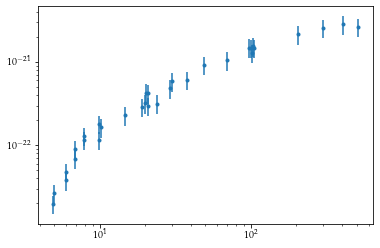

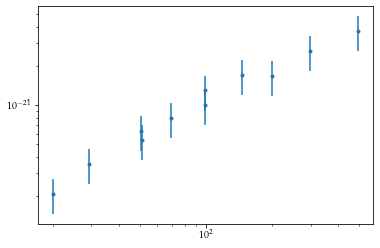

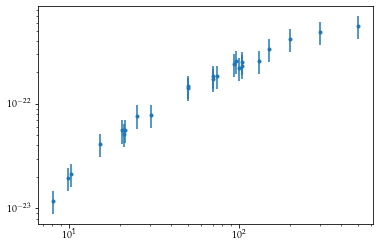

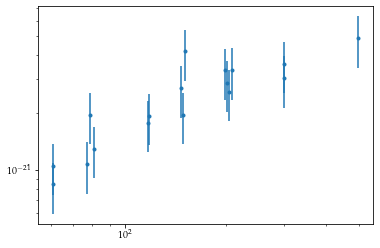

In [12]:
temp = np.copy(swarms[-1].datasets[0].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4
error = temp[:,1][...,None] * 0.25
a1 = np.append( temp, error, axis=1 )

filename = '../swarm/aex1.%s.txt' % refs[-1]
np.savetxt(filename,a1,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[-1].datasets[1].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4
error = temp[:,1][...,None] * 0.3
a2 = np.append( temp, error, axis=1 )

filename = '../swarm/aex2.%s.txt' % refs[-1]
np.savetxt(filename,a2,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[-1].datasets[2].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4
error = temp[:,1][...,None] * 0.25
a3 = np.append( temp, error, axis=1 )

filename = '../swarm/aex3.%s.txt' % refs[-1]
np.savetxt(filename,a3,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[-1].datasets[3].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4
error = temp[:,1][...,None] * 0.3
a4 = np.append( temp, error, axis=1 )

filename = '../swarm/aex4.%s.txt' % refs[-1]
np.savetxt(filename,a4,fmt='%.15E',delimiter=' ')

plt.figure(1)
plt.errorbar(a1[:,0],a1[:,1],yerr=a1[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

plt.figure(2)
plt.errorbar(a2[:,0],a2[:,1],yerr=a2[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

plt.figure(3)
plt.errorbar(a3[:,0],a3[:,1],yerr=a3[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

plt.figure(4)
plt.errorbar(a4[:,0],a4[:,1],yerr=a4[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')
